In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords

In [2]:
nltk.download('stopwords', quiet=True)

True

In [3]:
path_file = 'dataset_koreksi.csv'
print(f"{path_file}")

df = pd.read_csv(path_file)

df = df.dropna(subset=['clean_text']).reset_index(drop=True)

print(f"Jumlah baris: {len(df)}")

dataset_koreksi.csv
Jumlah baris: 8943


In [4]:
df['label'] = df['label'].astype(str).str.capitalize()
df['clean_text'] = df['clean_text'].astype(str)

In [5]:
sns.set(style="whitegrid")

C:\Users\Kevin\AppData\Local\Temp\ipykernel_21760\1972210356.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='label', data=df, order=urutan, palette=warna_batang)


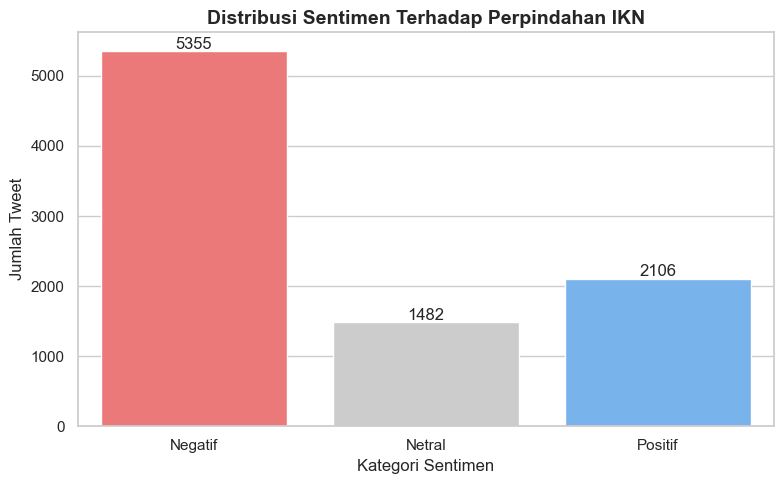

In [6]:
plt.figure(figsize=(8, 5))
# Membuat urutan grafik menjadi teratur: Negatif, Netral, Positif
urutan = ['Negatif', 'Netral', 'Positif']
warna_batang = ['#ff6666', '#cccccc', '#66b3ff'] # Merah, Abu-abu, Biru

ax = sns.countplot(x='label', data=df, order=urutan, palette=warna_batang)
plt.title('Distribusi Sentimen Terhadap Perpindahan IKN', fontsize=14, fontweight='bold')
plt.xlabel('Kategori Sentimen', fontsize=12)
plt.ylabel('Jumlah Tweet', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

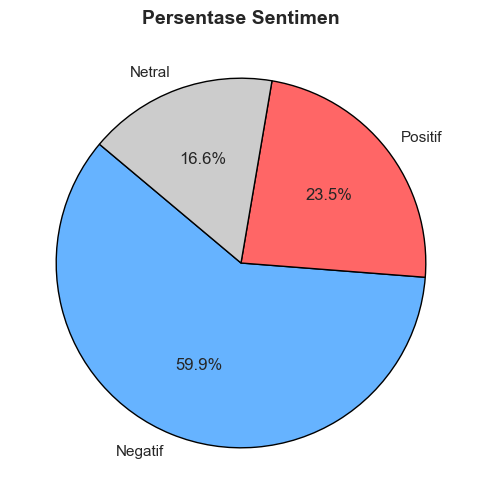

In [7]:
plt.figure(figsize=(6, 6))
jumlah_label = df['label'].value_counts()
warna_pie = ['#66b3ff', '#ff6666', '#cccccc'] # Menyesuaikan dengan urutan value_counts yang otomatis dari terbesar

plt.pie(jumlah_label, labels=jumlah_label.index, autopct='%1.1f%%',
        startangle=140, colors=warna_pie, wedgeprops={'edgecolor': 'black'})
plt.title('Persentase Sentimen', fontsize=14, fontweight='bold')
plt.show()


MEMUAT AWAN KATA (WORD CLOUD)...



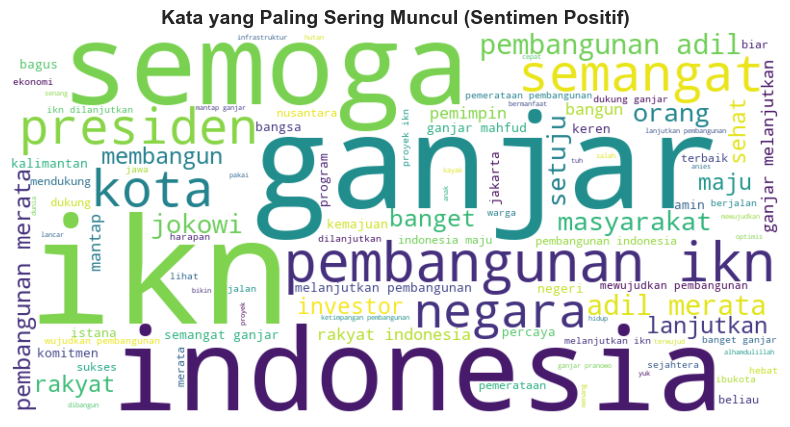

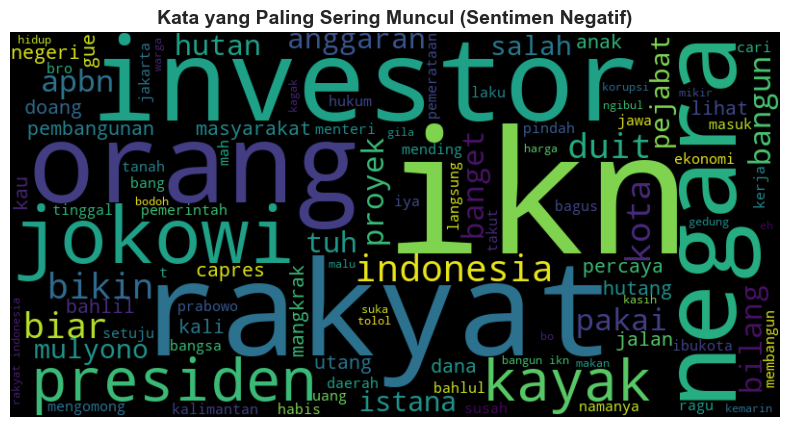

In [8]:
list_stopwords = set(stopwords.words('indonesian'))
kata_tambahan = {'yg', 'dgn', 'kalo', 'buat', 'pak', 'ya', 'sih', 'nya', 'nih', 'deh', 'kok', 'lu', 'lo', 'kan', 'dong', 'di', 'dan', 'ini', 'itu', 'untuk', 'yang', 'ke', 'dari', 'pada', 'dalam', 'dengan', 'saja', 'ada', 'adalah', 'akan'}
list_stopwords.update(kata_tambahan)

# Fungsi untuk membersihkan teks khusus untuk Word Cloud
def bersihkan_untuk_visualisasi(teks):
    kata_kata = str(teks).split()
    kata_bersih = [kata for kata in kata_kata if kata.lower() not in list_stopwords]
    return ' '.join(kata_bersih)

# Fungsi pembuat Word Cloud
def buat_wordcloud(teks_gabungan, judul, warna_latar):
    if not teks_gabungan.strip():
        print(f"Tidak ada data untuk {judul}")
        return

    wordcloud = WordCloud(width=800, height=400,
                          background_color=warna_latar,
                          colormap='viridis',
                          max_words=100).generate(teks_gabungan)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(judul, fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.show()

# Mengambil teks asli, lalu membersihkannya sebelum divisualisasikan
teks_positif_mentah = ' '.join(df[df['label'] == 'Positif']['clean_text'])
teks_positif_bersih = bersihkan_untuk_visualisasi(teks_positif_mentah)

teks_negatif_mentah = ' '.join(df[df['label'] == 'Negatif']['clean_text'])
teks_negatif_bersih = bersihkan_untuk_visualisasi(teks_negatif_mentah)

print("\nMEMUAT AWAN KATA (WORD CLOUD)...\n")
buat_wordcloud(teks_positif_bersih, 'Kata yang Paling Sering Muncul (Sentimen Positif)', 'white')
buat_wordcloud(teks_negatif_bersih, 'Kata yang Paling Sering Muncul (Sentimen Negatif)', 'black')